<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/capstoneproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt


In [ ]:
import io
df = pd.read_excel(io.BytesIO(uploaded['FINAL_DATASET_CAPSTONEPROJECT (1).xlsx'])) # Added a space at the end of the key

In [ ]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
complaints = pd.get_dummies(df['Chief Complaint'], drop_first=True)
df = pd.concat([df, complaints], axis=1)


In [ ]:
scaler = StandardScaler()
df['Age'] = scaler.fit_transform(df[['Age']])


In [ ]:
df['Outcome'] = np.random.randint(0, 2, size=len(df))


In [ ]:
X = df.drop(['Outcome', 'Chief Complaint', 'Patient Name', 'Patient ID', 'Contact No', 'Email', 'Health Center', 'Location'], axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
!pip install scikit-learn
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# ... your existing code ...

# Create an imputer to replace missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the features (X)
X = imputer.fit_transform(X)

# Now split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Continue with model training
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['Unnamed: 9']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred))

Accuracy: 0.47258064516129034
ROC-AUC Score: 0.5007332143490831
              precision    recall  f1-score   support

           0       0.47      1.00      0.64       586
           1       0.00      0.00      0.00       654

    accuracy                           0.47      1240
   macro avg       0.24      0.50      0.32      1240
weighted avg       0.22      0.47      0.30      1240



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


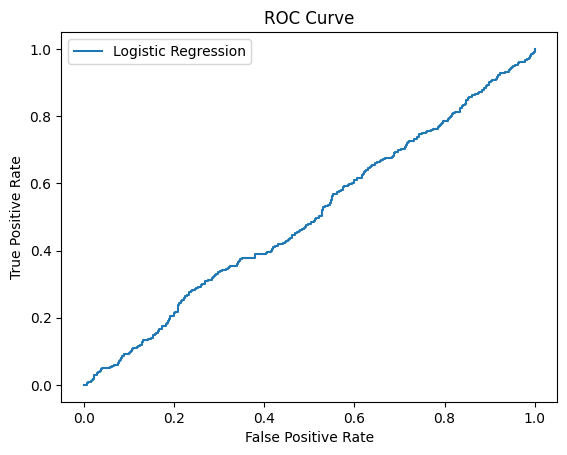

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression

# Assuming X_train and y_train are already defined and preprocessed
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
# Let's say you've standardized age during preprocessing:
age_mean = X_train[:, 0].mean() # Access the first column (assuming 'Age' was the first column) using numerical indexing
age_std = X_train[:, 0].std()   # Access the first column (assuming 'Age' was the first column) using numerical indexing

def get_user_input():
    age = int(input("Enter the patient's age: "))
    gender = input("Enter the patient's gender (M/F): ")

    # Normalize and encode inputs
    age_normalized = (age - age_mean) / age_std
    gender_encoded = 1 if gender.lower() == 'f' else 0  # Assuming 'M' is 0 and 'F' is 1

    return np.array([[age_normalized, gender_encoded]])

In [ ]:
# Store the mean and std for each feature
feature_means = X_train.mean(axis=0)
feature_stds = X_train.std(axis=0)

def get_user_input():
    user_input = []
    for i in range(18):  # Assuming 18 features
        value = float(input(f"Enter value for feature {i+1}: "))
        # Standardize the input
        value_normalized = (value - feature_means[i]) / feature_stds[i]
        user_input.append(value_normalized)
    return np.array([user_input])

In [ ]:
def get_user_input(feature_names):
    user_input = []
    for i, name in enumerate(feature_names):
        # Request input for each feature
        value = float(input(f"Enter value for {name}: "))
        # Standardize the input
        value_normalized = (value - feature_means[i]) / feature_stds[i]
        user_input.append(value_normalized)
    return np.array([user_input])

# Example feature names (you'll need to replace this with the actual list from your dataset)
feature_names = [
    "Age",
    "Sex",  # Remember to handle encoding if this is still categorical
    "Complaint_Headache",
    "Complaint_Cough",
    "Complaint_Fever",
    # Add other features...
]

# Get user inputs for each feature
user_input = get_user_input(feature_names)


Enter value for Age: 65
Enter value for Sex: F


ValueError: could not convert string to float: 'F'